# **Kenyan EV charging station location optimization using population** 

## **Business Understanding**

### **Overview** 

The adoption of electric vehicles (EVs) is increasing worldwide, creating a growing demand for reliable charging infrastructure. Proper planning of charging stations is important to ensure accessibility, reduce waiting times, and support sustainable transportation. This project focuses on analyzing charging station data to understand usage patterns and identify areas where infrastructure improvements are needed and to aid drivers in locating reliable charging stations with power and in close range distance.

### **Business Problem and Stakeholders**

The increase in electric vehicles in Kenya has created pressure on charging infrastructure https://www.the-star.co.ke/news/2026-02-11-ev-charging-drives-188-surge-in-kenyas-electricity-use?utm_source=copilot.com.

 Many areas lack sufficient charging stations, while others are underutilized https://techtrendske.co.ke/2025/09/28/kenya-ev-charging-stations-expansion-2030/?utm_source=copilot.com.
 
  This project aims to analyze and predict optimal charging station placement and usage to improve efficiency and accessibility.

At the same time, electric vehicle drivers face challenges in locating nearby charging stations and determining whether those stations are operational and have available power. This creates range anxiety, reduces user confidence, and may slow down the adoption of electric vehicles across the country.A Single Station Cuts Charging Time and Hints at What a Functioning National EV Network Might Finally Look Like https://techtrendske.co.ke/2025/11/19/kenya-ev-fast-charging-network/

The primary stakeholders for this problem are Government; Ministry of Transport and Ministry of Energy, EV charging investors, EV drivers and EV charging companies.The government uses the system for data-driven infrastructure planning, investors identify profitable charging locations, EV companies improve fleet operations and expansion decisions, and EV drivers gain easier access to reliable nearby charging stations.

### **Business Solution and Objectives** 

How can charging demand be forecasted using international datasets calibrated with Kenya's EV adoption statistics?
The proposed solution is the development of a smart, data-driven EV charging decision support system that combines geospatial analysis, machine learning, and predictive modeling to improve both infrastructure planning and driver accessibility. 

How can optimization algorithms recommend the best placement of new stations while considering grid reliability and identifying underserved areas for new charging stations?
For infrastructure planning, the project will use spatial data to estimate future EV charging demand across different locations. Supervised machine learning models such as Random Forest, Gradient Boosting or regression techniques will be used to generate a charging demand score for different areas, while clustering algorithms such as K-Means will identify high-demand hotspots and recommend optimal locations for new charging stations. 

How can drivers quickly locate the nearest and most reliable charging stations?
For driver support, the system will incorporate geospatial distance calculations and nearest-neighbor search to identify the closest charging stations, while classification or time-series models will be used to predict station availability and power status based on historical usage patterns, time of day, and day of week.

 Together, these methods will create an integrated system that helps stakeholders make informed infrastructure investment decisions while enabling EV drivers to easily locate nearby and reliable charging stations.

## **Data Understanding** 

The primary datasets for this project were sourced from HuggingFace, https://huggingface.co/datasets/tarekmasryo/global-ev-infra-dataset,

Kaggle, https://www.kaggle.com/datasets/paulmaluki/kenyapopulationdistibution-2019-censuscsv,

Fundi wa EV, https://www.fundiwaev.co.ke/ev_database and 

OCHA services, https://data.humdata.org/dataset/cod-ab-ken

The datasets utilized in this project are:
* `charging_station.csv` This dataset shows the locations of different charging stations across the world.

* `kenya_ev_charging_stations.csv` This dataset expounds deeper into charging stations in Kenya.

* `kenya-poulation-distribution-2019.csv` This dataset shows population density in different counties across Kenya.

* `ken_adminboundaries_tabulardata.xlsx` This dataset shows details on county boundaries across the country.

* `county_coordinates.csv` This dataset contains county coordinates that show their centroids.


In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import re
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)


In [96]:
# 1. Global charging stations
global_stations_df= pd.read_csv('./Data/charging_station.csv')
global_stations_df.head()

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
0,307660,Av. de Tarragona,Andorra,UNKNOWN,AD,42.505254,1.528861,10,300.0,DC_ULTRA_(>=150kW),True
1,301207,Parquing Costa Rodona,Encamp,UNKNOWN,AD,42.537213,1.727014,10,22.0,AC_HIGH_(22-49kW),False
2,301206,Hotel Naudi,Unknown City,UNKNOWN,AD,42.576811,1.666061,1,11.0,AC_L2_(7.5-21kW),False
3,301205,Hotel Piolets Soldeu Centre,Unknown City,UNKNOWN,AD,42.576466,1.667317,1,22.0,AC_HIGH_(22-49kW),False
4,301204,Hotel Serras,Unknown City,UNKNOWN,AD,42.579458,1.659215,3,11.0,AC_L2_(7.5-21kW),False


In [97]:
global_stations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242417 entries, 0 to 242416
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              242417 non-null  int64  
 1   name            242417 non-null  object 
 2   city            242417 non-null  object 
 3   state_province  242417 non-null  object 
 4   country_code    242417 non-null  object 
 5   latitude        242417 non-null  float64
 6   longitude       242417 non-null  float64
 7   ports           242417 non-null  int64  
 8   power_kw        237757 non-null  float64
 9   power_class     242417 non-null  object 
 10  is_fast_dc      242417 non-null  bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 18.7+ MB


In [98]:
global_stations_df['country_code'].unique()

array(['AD', 'AE', 'AF', 'AL', 'AM', 'AR', 'AT', 'AU', 'AX', 'AZ', 'BA',
       'BB', 'BE', 'BG', 'BH', 'BR', 'BW', 'BY', 'CA', 'CH', 'CL', 'CN',
       'CO', 'CR', 'CY', 'CZ', 'DE', 'DK', 'DO', 'EC', 'EE', 'EG', 'ES',
       'ET', 'FI', 'FO', 'FR', 'GB', 'GE', 'GG', 'GH', 'GI', 'GR', 'GT',
       'HK', 'HR', 'HU', 'ID', 'IE', 'IL', 'IM', 'IN', 'IQ', 'IS', 'IT',
       'JE', 'JM', 'JO', 'JP', 'KE', 'KG', 'KH', 'KR', 'KZ', 'LI', 'LK',
       'LT', 'LU', 'LV', 'MA', 'MC', 'MD', 'ME', 'MK', 'MM', 'MO', 'MT',
       'MX', 'MY', 'NAM', 'NL', 'NO', 'NP', 'NZ', 'OM', 'PA', 'PE', 'PH',
       'PK', 'PL', 'PR', 'PS', 'PT', 'PY', 'QA', 'RE', 'RO', 'RS', 'RU',
       'RW', 'SA', 'SE', 'SG', 'SI', 'SJ', 'SK', 'SM', 'SZ', 'TH', 'TN',
       'TR', 'TT', 'TW', 'UA', 'UG', 'US', 'UY', 'UZ', 'VN', 'XK', 'ZA'],
      dtype=object)

The above dataset shows there is Kenyan data which is represented by the Country code `KE`

In [99]:
kenya_stations1 = global_stations_df[global_stations_df['country_code'] == 'KE']
kenya_stations1

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
128395,267507,City Mall EvChaja,Unknown City,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW),False
128396,267505,Waiyaki Way,Unknown City,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW),False
128397,194150,Waterfront Mall EvChaja,Unknown City,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW),False
128398,194149,Two Rivers Mall EvChaja,Gachie,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW),False
128399,189881,Nopea Ride Village Market,Nairobi,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW),False
128400,189880,Nopea JKIA Airport,Nairobi,Nairobi,KE,-1.333731,36.928334,1,22.0,AC_HIGH_(22-49kW),False
128401,175802,Two Rivers Mall Nairobi (Nopea),Nairobi,Nairobi,KE,-1.211449,36.795808,1,11.0,AC_L2_(7.5-21kW),False
128402,175801,Sarit Centre Nairobi,Nairobi,Nairobi,KE,-1.261245,36.802243,1,22.0,AC_HIGH_(22-49kW),False
128403,175800,TRM Mall,Nairobi,Nairobi,KE,-1.219824,36.889224,2,22.0,AC_HIGH_(22-49kW),False
128404,175799,Holy Family Basilica Parking Silo,Nairobi,Nairobi,KE,-1.287358,36.820061,1,11.0,AC_L2_(7.5-21kW),False


In [100]:
kenya_stations1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12 entries, 128395 to 128406
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              12 non-null     int64  
 1   name            12 non-null     object 
 2   city            12 non-null     object 
 3   state_province  12 non-null     object 
 4   country_code    12 non-null     object 
 5   latitude        12 non-null     float64
 6   longitude       12 non-null     float64
 7   ports           12 non-null     int64  
 8   power_kw        12 non-null     float64
 9   power_class     12 non-null     object 
 10  is_fast_dc      12 non-null     bool   
dtypes: bool(1), float64(3), int64(2), object(5)
memory usage: 1.0+ KB


In [101]:
kenya_stations2= pd.read_csv('./Data/kenya_ev_charging_stations_sample_new.csv')
kenya_stations2.head()

,County/City,Station Name,Charger Type,Connector Types,Latitude,Longitude
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO",-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,Type2,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,Type2,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,Type2,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,Type2,-1.301320,36.812790


In [102]:
kenya_stations2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   County/City      16 non-null     object 
 1   Station Name     16 non-null     object 
 2   Charger Type     16 non-null     object 
 3   Connector Types  16 non-null     object 
 4   Latitude         16 non-null     float64
 5   Longitude        16 non-null     float64
dtypes: float64(2), object(4)
memory usage: 896.0+ bytes


This dataset shows charging infrastructure at city levels.

In [103]:
# 3. Kenyan population distribution
kenyan_population_df = pd.read_csv('./Data/kenya-population-distibution-2019-census.csv')
kenyan_population_df.head()

,County,Total,Male,Female,Intersex
0,KENYA,"14,831,700","7,352,134","7,478,883",683
1,Mombasa,"1,208,333","610,257","598,046",30
2,Kwale,"126,431","62,395","64,031",5
3,Kilifi,"393,888","191,324","202,558",6
4,Tana River,"75,722","37,854","37,867",1


This dataset shows a compact summary of the charging stations at country levels.

In [104]:
kenyan_population_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   County    48 non-null     object
 1   Total     48 non-null     object
 2   Male      48 non-null     object
 3   Female    48 non-null     object
 4   Intersex  48 non-null     object
dtypes: object(5)
memory usage: 2.0+ KB


In [105]:
ken_boundaries_df= pd.read_excel('./Data/ken_adminboundaries_tabulardata.xlsx')
ken_boundaries_df.head()

,OBJECTID *,Shape *,admin2Name_en,admin2Pcode,admin2RefName,admin2AltName1_en,admin2AltName2_en,admin1Name_en,admin1Pcode,admin0Name_en,admin0Pcode,date,validOn,validTo,Shape_Length,Shape_Area
0,1,Polygon,Ainabkoi,KE027144,<Null>,<Null>,<Null>,Uasin Gishu,KE027,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.746986,0.040829
1,2,Polygon,Ainamoi,KE035190,<Null>,<Null>,<Null>,Kericho,KE035,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.917307,0.019957
2,3,Polygon,Aldai,KE029152,<Null>,<Null>,<Null>,Nandi,KE029,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.402637,0.038000
3,4,Polygon,Alego Usonga,KE041234,<Null>,<Null>,<Null>,Siaya,KE041,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.081354,0.049357
4,5,Polygon,Awendo,KE044254,<Null>,<Null>,<Null>,Migori,KE044,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.743915,0.021365


In [106]:
ken_boundaries_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OBJECTID *         290 non-null    int64         
 1   Shape *            290 non-null    object        
 2   admin2Name_en      290 non-null    object        
 3   admin2Pcode        290 non-null    object        
 4   admin2RefName      290 non-null    object        
 5   admin2AltName1_en  290 non-null    object        
 6   admin2AltName2_en  290 non-null    object        
 7   admin1Name_en      290 non-null    object        
 8   admin1Pcode        290 non-null    object        
 9   admin0Name_en      290 non-null    object        
 10  admin0Pcode        290 non-null    object        
 11  date               290 non-null    datetime64[ns]
 12  validOn            290 non-null    datetime64[ns]
 13  validTo            290 non-null    object        
 14  Shape_Leng

In [107]:
county_coords = pd.read_csv("./Data/county_coordinates.csv")
county_coords.head()

,county,Latitude,Longitude
0,Uasin Gishu,0.516667,35.283300
1,Kericho,-0.367740,35.283140
2,Nandi,0.166667,35.150000
3,Siaya,-0.083333,34.249999
4,Nakuru,-0.283332,36.066666


In [108]:
county_coords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   county     47 non-null     object 
 1   Latitude   47 non-null     float64
 2   Longitude  47 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.2+ KB


## **Data Cleaning and Preparation**

### **Data Cleaning**

In [109]:
kenya_stations1.duplicated().sum()

0

In [110]:
kenya_stations1.isnull().sum()

id                0
name              0
city              0
state_province    0
country_code      0
latitude          0
longitude         0
ports             0
power_kw          0
power_class       0
is_fast_dc        0
dtype: int64

In [111]:
kenya_stations2.duplicated().sum()

0

In [112]:
kenya_stations2.isnull().sum()

County/City        0
Station Name       0
Charger Type       0
Connector Types    0
Latitude           0
Longitude          0
dtype: int64

In [113]:
kenyan_population_df.duplicated().sum()

0

In [114]:
kenyan_population_df.isnull().sum()

County      0
Total       0
Male        0
Female      0
Intersex    0
dtype: int64

In [115]:
ken_boundaries_df.duplicated().sum()

0

In [116]:
ken_boundaries_df.isnull().sum()

OBJECTID *           0
Shape *              0
admin2Name_en        0
admin2Pcode          0
admin2RefName        0
admin2AltName1_en    0
admin2AltName2_en    0
admin1Name_en        0
admin1Pcode          0
admin0Name_en        0
admin0Pcode          0
date                 0
validOn              0
validTo              0
Shape_Length         0
Shape_Area           0
dtype: int64

In [117]:
county_coords.duplicated().sum()

0

In [118]:
county_coords.isnull().sum()

county       0
Latitude     0
Longitude    0
dtype: int64

### **Data Preparation**


#### **Kenya Stations1 Preparation**

In [119]:
kenya_stations1.head()

,id,name,city,state_province,country_code,latitude,longitude,ports,power_kw,power_class,is_fast_dc
128395,267507,City Mall EvChaja,Unknown City,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW),False
128396,267505,Waiyaki Way,Unknown City,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW),False
128397,194150,Waterfront Mall EvChaja,Unknown City,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW),False
128398,194149,Two Rivers Mall EvChaja,Gachie,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW),False
128399,189881,Nopea Ride Village Market,Nairobi,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW),False


In [120]:
kenya_stations1 = kenya_stations1.drop(columns=['id', 'city', 'is_fast_dc'])
kenya_stations1.head()

,name,state_province,country_code,latitude,longitude,ports,power_kw,power_class
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,22.0,AC_HIGH_(22-49kW)
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,22.0,AC_HIGH_(22-49kW)
128397,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1,22.0,AC_HIGH_(22-49kW)
128398,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1,11.0,AC_L2_(7.5-21kW)
128399,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1,22.0,AC_HIGH_(22-49kW)


In [121]:
kenya_stations1= kenya_stations1.rename(columns={"state_province": "county", "name": "station name"})

In [122]:
kenya_stations1['county'].value_counts()

Nairobi    11
Mombasa     1
Name: county, dtype: int64

In [123]:
kenya_stations1["charger type"] = kenya_stations1["power_class"].str.split("_").str[0].str.upper()

In [124]:
kenya_stations1 = kenya_stations1.drop(columns = ["power_class", "power_kw"])

In [125]:
kenya_stations1.head(2)

,station name,county,country_code,latitude,longitude,ports,charger type
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,AC
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,AC


#### **Kenya Stations2 Preparation**

In [126]:
kenya_stations2.head()

,County/City,Station Name,Charger Type,Connector Types,Latitude,Longitude
0,Nairobi,Sarit Centre,AC + DC,"Type2, CHAdeMO",-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,Type2,-1.210229,36.795216
2,Nairobi,Village Market Gigiri,AC,Type2,-1.227277,36.805228
3,Nairobi,UNGA House Westlands,AC,Type2,-1.262890,36.804670
4,Nairobi,KCB Towers Upper Hill,AC,Type2,-1.301320,36.812790


In [127]:
kenya_stations2 =kenya_stations2.drop(columns='Connector Types')

In [128]:
kenya_stations2= kenya_stations2.rename(columns={"County/City": "county", "Station Name": "station name", "Charger Type": "charger type", "Latitude": "latitude", "Longitude": "longitude"})

In [129]:
kenya_stations2['county'].value_counts()

Nairobi     9
Kiambu      1
Mombasa     1
Naivasha    1
Kisumu      1
Narok       1
Mavoko      1
Nakuru      1
Name: county, dtype: int64

In [130]:
kenya_stations2['county'] = kenya_stations2['county'].replace(['Mavoko', 'Naivasha'], ['Machakos', 'Nakuru'])

In [131]:
kenya_stations2['county'].value_counts()

Nairobi     9
Nakuru      2
Kiambu      1
Machakos    1
Mombasa     1
Kisumu      1
Narok       1
Name: county, dtype: int64

In [132]:
kenya_stations2.head(2)

,county,station name,charger type,latitude,longitude
0,Nairobi,Sarit Centre,AC + DC,-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,-1.210229,36.795216


#### **Population Preparation**

In [133]:
kenyan_population_df

,County,Total,Male,Female,Intersex
0,KENYA,"14,831,700","7,352,134","7,478,883",683
1,Mombasa,"1,208,333","610,257","598,046",30
2,Kwale,"126,431","62,395","64,031",5
3,Kilifi,"393,888","191,324","202,558",6
4,Tana River,"75,722","37,854","37,867",1
5,Lamu,"38,446","19,533","18,911",2
6,Taita/Taveta,"93,774","46,620","47,149",5
7,Garissa,"210,890","109,552","101,331",7
8,Wajir,"177,174","94,812","82,340",22
9,Mandera,"270,467","135,548","134,909",10


In [134]:
kenyan_population_df = kenyan_population_df.drop(columns=['Male', 'Female', 'Intersex'])

In [135]:
kenyan_population_df = kenyan_population_df.rename(columns={"County": "county", "Total": "population"})

In [136]:
kenyan_population_df = kenyan_population_df[kenyan_population_df['county'] != 'KENYA']

In [137]:
kenyan_population_df['county'] = kenyan_population_df['county'].replace(['Nairobi City', 'Elg eyo/Marakwet', 'Taita/Taveta'], ['Nairobi', 'Elgeyo-Marakwet', 'Taita Taveta'])

In [138]:
kenyan_population_df['population'] = kenyan_population_df['population'].str.replace(',', '').astype(int)

In [139]:
kenyan_population_df.head(2)

,county,population
1,Mombasa,1208333
2,Kwale,126431


#### **Kenya Admin Boundaries Preparation**

In [140]:
ken_boundaries_df.head()

,OBJECTID *,Shape *,admin2Name_en,admin2Pcode,admin2RefName,admin2AltName1_en,admin2AltName2_en,admin1Name_en,admin1Pcode,admin0Name_en,admin0Pcode,date,validOn,validTo,Shape_Length,Shape_Area
0,1,Polygon,Ainabkoi,KE027144,<Null>,<Null>,<Null>,Uasin Gishu,KE027,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.746986,0.040829
1,2,Polygon,Ainamoi,KE035190,<Null>,<Null>,<Null>,Kericho,KE035,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.917307,0.019957
2,3,Polygon,Aldai,KE029152,<Null>,<Null>,<Null>,Nandi,KE029,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.402637,0.038000
3,4,Polygon,Alego Usonga,KE041234,<Null>,<Null>,<Null>,Siaya,KE041,Kenya,KE,2017-11-03,2018-06-07,<Null>,1.081354,0.049357
4,5,Polygon,Awendo,KE044254,<Null>,<Null>,<Null>,Migori,KE044,Kenya,KE,2017-11-03,2018-06-07,<Null>,0.743915,0.021365


In [141]:
ken_boundaries_df = ken_boundaries_df.rename(columns={"admin1Name_en": "county","admin2Name_en": "sub county", "admin0Pcode": "country code", "Shape_Area": "shape area", "Shape_Length": "shape length"})

In [142]:
ken_boundaries_df = ken_boundaries_df[['county', 'sub county', 'country code', 'shape area', 'shape length']]

In [143]:
ken_boundaries_df

,county,sub county,country code,shape area,shape length
0,Uasin Gishu,Ainabkoi,KE,0.040829,1.746986
1,Kericho,Ainamoi,KE,0.019957,0.917307
2,Nandi,Aldai,KE,0.038000,1.402637
3,Siaya,Alego Usonga,KE,0.049357,1.081354
4,Migori,Awendo,KE,0.021365,0.743915
...,...,...,...,...,...
285,Bungoma,Webuye West,KE,0.019180,1.010876
286,Nyamira,West Mugirango,KE,0.014610,0.630183
287,Nairobi,Westlands,KE,0.005908,0.405298
288,Taita Taveta,Wundanyi,KE,0.069243,1.214526


#### **County Coordinates Preparation**

In [144]:
county_coords.head(2)

,county,Latitude,Longitude
0,Uasin Gishu,0.516667,35.28330
1,Kericho,-0.367740,35.28314


In [145]:
county_coords = county_coords.rename(columns={"Latitude": "county_lat", "Longitude": "county_lon"})

In [146]:
county_coords.head(2)

,county,county_lat,county_lon
0,Uasin Gishu,0.516667,35.28330
1,Kericho,-0.367740,35.28314


#### **Final Stations and Counties Dataframes Preparation**

##### **Final Stations**

Merging all the stations from `kenyastations1` and from `kenyastations2` together

In [147]:
kenya_stations1.head(2)

,station name,county,country_code,latitude,longitude,ports,charger type
128395,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1,AC
128396,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1,AC


In [148]:
kenya_stations2.head(2)

,county,station name,charger type,latitude,longitude
0,Nairobi,Sarit Centre,AC + DC,-1.261245,36.802243
1,Nairobi,Two Rivers Mall,AC,-1.210229,36.795216


In [149]:
# Combine all rows from both dataframes
kenya_stations = pd.concat([kenya_stations1, kenya_stations2], ignore_index=True)
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [150]:
kenya_stations = kenya_stations.drop_duplicates(subset=['latitude', 'longitude'], keep='first')
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


In [151]:
kenya_stations.isnull().sum()

station name     0
county           0
country_code    12
latitude         0
longitude        0
ports           12
charger type     0
dtype: int64

In [152]:
kenya_stations['country_code'] = kenya_stations['country_code'].fillna('KE')

In [153]:
kenya_stations['ports'] = kenya_stations['ports'].fillna(1.0)

In [154]:
kenya_stations.isnull().sum()

station name    0
county          0
country_code    0
latitude        0
longitude       0
ports           0
charger type    0
dtype: int64

In [155]:
kenya_stations

,station name,county,country_code,latitude,longitude,ports,charger type
0,City Mall EvChaja,Mombasa,KE,-4.020064,39.720491,1.0,AC
1,Waiyaki Way,Nairobi,KE,-1.259614,36.776883,1.0,AC
2,Waterfront Mall EvChaja,Nairobi,KE,-1.329425,36.715820,1.0,AC
3,Two Rivers Mall EvChaja,Nairobi,KE,-1.210229,36.795216,1.0,AC
4,Nopea Ride Village Market,Nairobi,KE,-1.227277,36.805228,1.0,AC
5,Nopea JKIA Airport,Nairobi,KE,-1.333731,36.928334,1.0,AC
6,Two Rivers Mall Nairobi (Nopea),Nairobi,KE,-1.211449,36.795808,1.0,AC
7,Sarit Centre Nairobi,Nairobi,KE,-1.261245,36.802243,1.0,AC
8,TRM Mall,Nairobi,KE,-1.219824,36.889224,2.0,AC
9,Holy Family Basilica Parking Silo,Nairobi,KE,-1.287358,36.820061,1.0,AC


##### **Final Counties Dataframe**

In [156]:
county_df = kenyan_population_df.merge(county_coords, on='county', how='left')
county_df.head()

,county,population,county_lat,county_lon
0,Mombasa,1208333,-4.054660,39.663590
1,Kwale,126431,-4.171333,39.456164
2,Kilifi,393888,-3.666670,39.750000
3,Tana River,75722,-1.533330,39.416670
4,Lamu,38446,-2.271690,40.902010


In [157]:
station_counts = kenya_stations.groupby('county').size().reset_index(name='num_stations')
station_counts

,county,num_stations
0,Kiambu,1
1,Kisumu,1
2,Machakos,1
3,Mombasa,1
4,Nairobi,17
5,Nakuru,2
6,Narok,1


In [158]:
county_df = county_df.merge(station_counts, on='county', how='left')
county_df.head()

,county,population,county_lat,county_lon,num_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0
1,Kwale,126431,-4.171333,39.456164,NaN
2,Kilifi,393888,-3.666670,39.750000,NaN
3,Tana River,75722,-1.533330,39.416670,NaN
4,Lamu,38446,-2.271690,40.902010,NaN


In [159]:
county_df['num_stations'] = county_df['num_stations'].fillna(0)

In [160]:
county_df.head(15)

,county,population,county_lat,county_lon,num_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0
1,Kwale,126431,-4.171333,39.456164,0.0
2,Kilifi,393888,-3.666670,39.750000,0.0
3,Tana River,75722,-1.533330,39.416670,0.0
4,Lamu,38446,-2.271690,40.902010,0.0
5,Taita Taveta,93774,-3.333332,38.249999,0.0
6,Garissa,210890,-0.452750,39.646010,0.0
7,Wajir,177174,1.747220,40.068900,0.0
8,Mandera,270467,3.416670,40.666700,0.0
9,Marsabit,107239,2.328390,37.989860,0.0


In [161]:
# Rebuild county area properly
county_area = (ken_boundaries_df.groupby("county", as_index=False)["shape area"].sum())
county_area.head()

,county,shape area
0,Baringo,0.884732
1,Bomet,0.198098
2,Bungoma,0.245060
3,Busia,0.147178
4,Elgeyo-Marakwet,0.244432


In [162]:
county_df = county_df.merge(county_area[['county', 'shape area']], on='county', how='left')
county_df

,county,population,county_lat,county_lon,num_stations,shape area
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574
5,Taita Taveta,93774,-3.333332,38.249999,0.0,1.394198
6,Garissa,210890,-0.452750,39.646010,0.0,3.542187
7,Wajir,177174,1.747220,40.068900,0.0,4.606490
8,Mandera,270467,3.416670,40.666700,0.0,2.114345
9,Marsabit,107239,2.328390,37.989860,0.0,6.185190


## **Feature Engineering**

## **EDA** 

In [183]:
county_df['stations_per_100k'] = (county_df['num_stations'] / county_df['population']) * 100000
county_df.head(2)

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,infrastructure_gap,predicted_stations,additional_stations_needed,population_per_station
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,3.175812e+07,3.5,2,1208333.0
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,1.877904e+05,0.0,0,126431.0


In [182]:
county_df['population_density'] = (county_df['population'] / county_df['shape area'])
county_df.head(2)

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,infrastructure_gap,predicted_stations,additional_stations_needed,population_per_station
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,3.175812e+07,3.5,2,1208333.0
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,1.877904e+05,0.0,0,126431.0


In [181]:
# if zero stations use population as the value to avoid division by zero
county_df["population_per_station"] = np.where(
    county_df["num_stations"] > 0,
    county_df["population"] / county_df["num_stations"],
    county_df["population"]
)
county_df.head(2)

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,infrastructure_gap,predicted_stations,additional_stations_needed,population_per_station
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,3.175812e+07,3.5,2,1208333.0
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,1.877904e+05,0.0,0,126431.0


In [184]:
# concentration_of_stations
county_df["station_spatial_density"] = (county_df["num_stations"] / county_df["shape area"])
county_df.head(2)

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,infrastructure_gap,predicted_stations,additional_stations_needed,population_per_station,station_spatial_density
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,3.175812e+07,3.5,2,1208333.0,52.565181
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,1.877904e+05,0.0,0,126431.0,0.000000


In [185]:
county_df["required_stations"] = np.ceil(county_df["population"] / 200000)

# Ensure minimum 1 per county
county_df["required_stations"] = county_df["required_stations"].apply(lambda x: max(1, x))

In [186]:
county_df["additional_stations"] = (
    county_df["required_stations"] - county_df["num_stations"]
)

county_df["additional_stations"] = county_df["additional_stations"].apply(lambda x: max(0, x))
county_df

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,infrastructure_gap,predicted_stations,additional_stations_needed,population_per_station,station_spatial_density,required_stations,additional_stations
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,3.175812e+07,3.50,2,1.208333e+06,52.565181,7.0,6.0
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,1.877904e+05,0.00,0,1.264310e+05,0.000000,1.0,1.0
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128,0.000000,3.842330e+05,3.842330e+05,0.11,0,3.938880e+05,0.000000,2.0,2.0
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405,0.000000,2.377155e+04,2.377155e+04,0.00,0,7.572200e+04,0.000000,1.0,1.0
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574,0.000000,7.820999e+04,7.820999e+04,0.00,0,3.844600e+04,0.000000,1.0,1.0
5,Taita Taveta,93774,-3.333332,38.249999,0.0,1.394198,0.000000,6.726017e+04,6.726017e+04,0.05,0,9.377400e+04,0.000000,1.0,1.0
6,Garissa,210890,-0.452750,39.646010,0.0,3.542187,0.000000,5.953666e+04,5.953666e+04,0.00,0,2.108900e+05,0.000000,2.0,2.0
7,Wajir,177174,1.747220,40.068900,0.0,4.606490,0.000000,3.846182e+04,3.846182e+04,0.00,0,1.771740e+05,0.000000,1.0,1.0
8,Mandera,270467,3.416670,40.666700,0.0,2.114345,0.000000,1.279200e+05,1.279200e+05,0.14,0,2.704670e+05,0.000000,2.0,2.0
9,Marsabit,107239,2.328390,37.989860,0.0,6.185190,0.000000,1.733803e+04,1.733803e+04,0.06,0,1.072390e+05,0.000000,1.0,1.0


Ev Stations Distribution by County

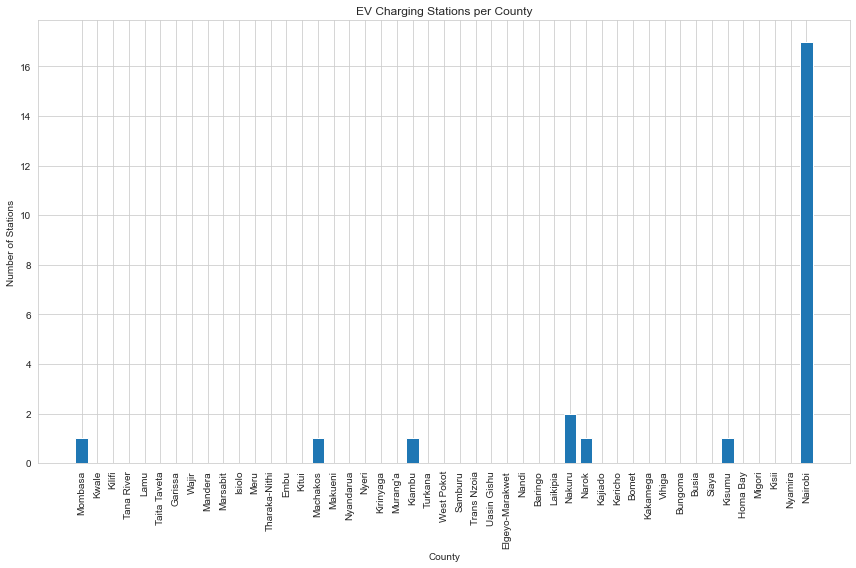

In [163]:


plt.figure()
plt.bar(county_df['county'], county_df['num_stations'])
plt.xticks(rotation=90)
plt.title("EV Charging Stations per County")
plt.xlabel("County")
plt.ylabel("Number of Stations")
plt.tight_layout()
plt.show()


Population Distribution

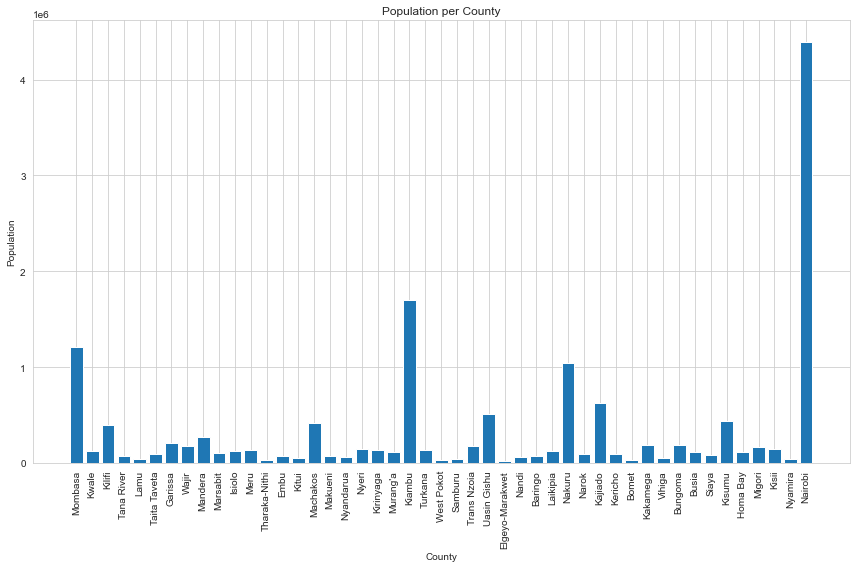

In [164]:
plt.figure()
plt.bar(county_df['county'], county_df['population'])
plt.xticks(rotation=90)
plt.title("Population per County")
plt.xlabel("County")
plt.ylabel("Population")
plt.tight_layout()
plt.show()


Station vs Population Relationship

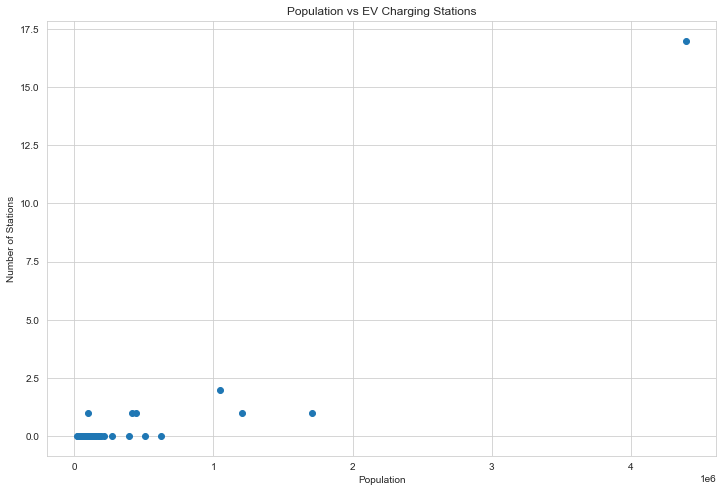

In [165]:
plt.figure()
plt.scatter(county_df['population'], county_df['num_stations'])
plt.title("Population vs EV Charging Stations")
plt.xlabel("Population")
plt.ylabel("Number of Stations")
plt.show()


# Feature Engineering

Stations per 100,000 People


In [166]:
county_df['stations_per_100k'] = (
    county_df['num_stations'] / county_df['population']
) * 100000
county_df.head()

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128,0.000000
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405,0.000000
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574,0.000000


Population Density

In [167]:
county_df['population_density'] = (
    county_df['population'] / county_df['shape area']
)
county_df.head()

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128,0.000000,3.842330e+05
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405,0.000000,2.377155e+04
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574,0.000000,7.820999e+04


Infrastructure Gap (Demand Proxy)

In [168]:
county_df['infrastructure_gap'] = (
    county_df['population_density'] / (county_df['num_stations'] + 1)
)
county_df.head()

,county,population,county_lat,county_lon,num_stations,shape area,stations_per_100k,population_density,infrastructure_gap
0,Mombasa,1208333,-4.054660,39.663590,1.0,0.019024,0.082759,6.351624e+07,3.175812e+07
1,Kwale,126431,-4.171333,39.456164,0.0,0.673256,0.000000,1.877904e+05,1.877904e+05
2,Kilifi,393888,-3.666670,39.750000,0.0,1.025128,0.000000,3.842330e+05,3.842330e+05
3,Tana River,75722,-1.533330,39.416670,0.0,3.185405,0.000000,2.377155e+04,2.377155e+04
4,Lamu,38446,-2.271690,40.902010,0.0,0.491574,0.000000,7.820999e+04,7.820999e+04


Machine Learning – EV Demand Prediction Model

In [169]:

X = county_df[['population', 'population_density']]
y = county_df['num_stations']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train Random Forest Model

In [170]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [171]:
y_pred = model.predict(X_test)


Model Evaluation

In [172]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Absolute Error: 0.098
R2 Score: 0.0


Predict Optimal Required Stations Per County

In [173]:
county_df['predicted_stations'] = model.predict(
    county_df[['population', 'population_density']]
)


Calculate Required Additional Stations

In [174]:
county_df['additional_stations_needed'] = (
    county_df['predicted_stations'] - county_df['num_stations']
)

county_df['additional_stations_needed'] = (
    county_df['additional_stations_needed'].apply(lambda x: round(x) if x > 0 else 0)
)


Rank Counties for EV Expansion Priority

In [175]:
county_priority = county_df.sort_values(
    by='additional_stations_needed',
    ascending=False
)

county_priority[['county', 'num_stations',
                 'predicted_stations',
                 'additional_stations_needed']].head(10)


,county,num_stations,predicted_stations,additional_stations_needed
0,Mombasa,1.0,3.50,2
26,Uasin Gishu,0.0,0.80,1
35,Bomet,0.0,0.05,0
27,Elgeyo-Marakwet,0.0,0.00,0
28,Nandi,0.0,0.00,0
29,Baringo,0.0,0.00,0
30,Laikipia,0.0,0.00,0
31,Nakuru,2.0,1.47,0
32,Narok,1.0,0.65,0
33,Kajiado,0.0,0.40,0


Visual Map of Priority Counties

In [176]:
import folium

kenya_map = folium.Map(location=[-0.0236, 37.9062], zoom_start=6)

for _, row in county_priority.iterrows():
    folium.CircleMarker(
        location=[-0.0236, 37.9062],  # replace with county centroid if available
        radius=row['additional_stations_needed'] + 2,
        popup=row['county'],
        fill=True
    ).add_to(kenya_map)

kenya_map


Final Dataset for Optimization

In [177]:
final_output = county_df[[
    'county',
    'population',
    'population_density',
    'num_stations',
    'predicted_stations',
    'additional_stations_needed'
]]

final_output.to_csv("kenya_ev_expansion_plan.csv", index=False)

final_output.head()


,county,population,population_density,num_stations,predicted_stations,additional_stations_needed
0,Mombasa,1208333,6.351624e+07,1.0,3.50,2
1,Kwale,126431,1.877904e+05,0.0,0.00,0
2,Kilifi,393888,3.842330e+05,0.0,0.11,0
3,Tana River,75722,2.377155e+04,0.0,0.00,0
4,Lamu,38446,7.820999e+04,0.0,0.00,0
